In [1]:
import yaml
import os
import numpy as np
import pandas as pd

In [2]:
v_rel = np.sqrt(39 * 2 * 1e3 * 0.39 / 0.02)  # Relative velocity in m/s
print(f"Relative velocity (x-direction): {v_rel:.2f} m/s")

Relative velocity (x-direction): 1233.29 m/s


In [4]:
base_path = os.path.abspath("")
config_folder = os.path.join(base_path, "configs")
io_folder = os.path.join(base_path, "input-output")

os.makedirs(config_folder, exist_ok=True)
os.makedirs(io_folder, exist_ok=True)

# 2. Definiamo i path dei file che scriveremo
config_file_path = os.path.join(config_folder, "model_config.yaml")
data_file_path = os.path.join(config_folder, "data.yaml")

In [12]:
config = {
    "simulation": {
        "minimalCharacteristicLength": 0.00027,
        "simulationType": "COLLISION",
        "inputSource": [data_file_path]  # Percorso assoluto a data.yaml
    },
    "inputOutput": {
        "target": [
            os.path.join(io_folder, "input.csv"), 
            os.path.join(io_folder, "input.vtu")
        ],
        "kepler": False
    },
    "resultOutput": {
        "target": [
            os.path.join(io_folder, "result.csv"), 
            os.path.join(io_folder, "result.vtu")
        ],
        "kepler": False
    }
}

data = {
    "satellites": [
        {
            "id": 1, "name": "Target", "satType": "SPACECRAFT",
            "mass": 0.39, "area": 0.01, "position": [100000, 0, 0], "velocity": [0, 0, 0]
        },
        {
            "id": 2, "name": "Projectile", "satType": "SPACECRAFT",
            "mass": 0.02, "area": 0.0002, "position": [100000, 0, 0], "velocity": [1233.29, 0, 0]
        }
    ]
}

In [13]:
with open(config_file_path, 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=None)

with open(data_file_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False, default_flow_style=None)

In [14]:
exe_dir = "../../build"
!cd {exe_dir} && ./breakupModel {config_file_path}

[2026-03-24 17:07:06.673] [info] The simulation took 17 ms
[2026-03-24 17:07:06.674] [info] The simulation produced 9220 fragments


In [15]:
import pyvista as pv

/home/andrea/miniconda3/envs/myenv/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


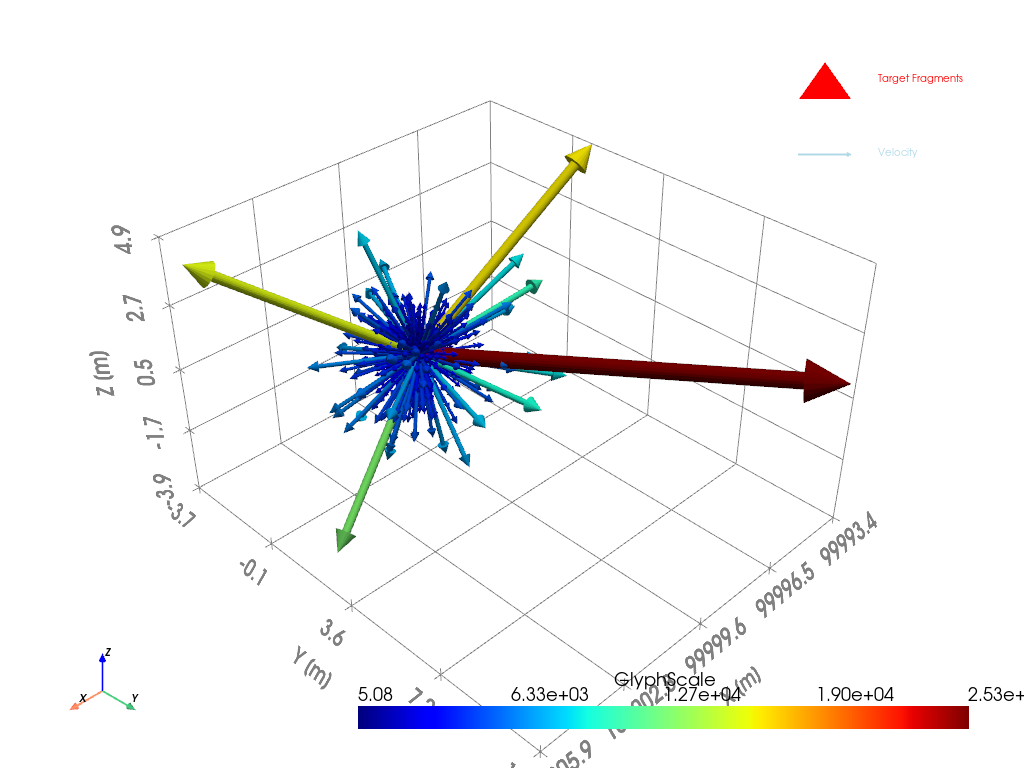

In [16]:
vtu_file = os.path.abspath("input-output/result.vtu")
mesh = pv.read(vtu_file)

ids = mesh.point_data["id"]
mask = ids < 8163
indices = np.where(mask)[0]

filtered_mesh = pv.PolyData(mesh.points[indices])


for key in mesh.point_data.keys():
    filtered_mesh.point_data[key] = mesh.point_data[key][indices]

vector_name = "velocity"
filtered_mesh.set_active_vectors(vector_name)

arrows = filtered_mesh.glyph(
    orient=vector_name,
    scale=vector_name,
    factor=0.0005,
    geom=pv.Arrow(tip_length=0.1, tip_radius=0.05, shaft_radius=0.02)
)

plotter = pv.Plotter(notebook=True)

plotter.add_mesh(
    filtered_mesh,
    color='red',
    render_points_as_spheres=True,
    point_size=10,
    label='Target Fragments'
)

plotter.add_mesh(arrows, cmap='jet', label='Velocity')
plotter.show_grid(color='gray', xtitle='X [m]', ytitle='Y [m]', ztitle='Z [m]')

plotter.add_axes()
plotter.add_legend()
plotter.show()

In [13]:
# The final kinetic energy is the sum of the kinetic energies of all fragments after the collision.
# The fragments' velocities can be found in /input-output/result.csv in the column "velocity". We can read this file and compute the kinetic energy.
output_dir = os.path.join(base_path, "input-output")
output_file = os.path.join(output_dir, "result.csv")
df = pd.read_csv(output_file)

def parse_velocity(val):
    # Removing spaces and handling the specific formatting in your error message
    clean_val = val.replace(' ', ',').replace(',,', ',')
    return np.array(ast.literal_eval(clean_val))

# Apply the parser to the velocity column
velocities = df["Velocity [m/s]"].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))

In [15]:
# Check energy conservation

# We define initial energy as the sum of the kinetic energies of the system before the collision.

initial_kinetic_energy = 0.5 * 0.02 * v_rel**2

# We define final energy as the sum of the kinetic energies of all fragments after the collision.
velocities_array = np.array(velocities.tolist())
final_kinetic_energy = 0.5 * np.sum(df["Mass [kg]"] * np.linalg.norm(velocities_array, axis=1)**2)
print(f"Initial kinetic energy: {initial_kinetic_energy:.2f} J")
print(f"Final kinetic energy: {final_kinetic_energy:.2f} J")
# Percent difference
percent_difference = 100 * abs(final_kinetic_energy - initial_kinetic_energy)
print(f"Percent difference: {percent_difference:.2f}%")


Initial kinetic energy: 15210.00 J
Final kinetic energy: 7590.49 J
Percent difference: 761951.39%


In [16]:
# Momentum conservation for each direction
initial_momentum_x = 0.02 * v_rel
final_momentum_x = np.sum(df["Mass [kg]"] * velocities_array[:, 0])
print(f"Initial momentum (x-direction): {initial_momentum_x:.2f} kg*m/s")
print(f"Final momentum (x-direction): {final_momentum_x:.2f} kg*m/s")
percent_difference_momentum_x = 100 * abs(final_momentum_x - initial_momentum_x) / abs(initial_momentum_x)
print(f"Percent difference in momentum (x-direction): {percent_difference_momentum_x:.2f}%")

initial_momentum_y = 0
final_momentum_y = np.sum(df["Mass [kg]"] * velocities_array[:, 1])
print(f"Initial momentum (y-direction): {initial_momentum_y:.2f} kg*m/s")
print(f"Final momentum (y-direction): {final_momentum_y:.2f} kg*m/s")
percent_difference_momentum_y = 100 * abs(final_momentum_y - initial_momentum_y) / (abs(initial_momentum_y) + 1e-10)
print(f"Percent difference in momentum (y-direction): {percent_difference_momentum_y:.2f}%")

initial_momentum_z = 0
final_momentum_z = np.sum(df["Mass [kg]"] * velocities_array[:, 2])
print(f"Initial momentum (z-direction): {initial_momentum_z:.2f} kg*m/s")
print(f"Final momentum (z-direction): {final_momentum_z:.2f} kg*m/s")
percent_difference_momentum_z = 100 * abs(final_momentum_z - initial_momentum_z) / (abs(initial_momentum_z) + 1e-10)
print(f"Percent difference in momentum (z-direction): {percent_difference_momentum_z:.2f}%")

Initial momentum (x-direction): 24.67 kg*m/s
Final momentum (x-direction): 2.49 kg*m/s
Percent difference in momentum (x-direction): 89.90%
Initial momentum (y-direction): 0.00 kg*m/s
Final momentum (y-direction): -1.10 kg*m/s
Percent difference in momentum (y-direction): 1098228825995.73%
Initial momentum (z-direction): 0.00 kg*m/s
Final momentum (z-direction): -0.36 kg*m/s
Percent difference in momentum (z-direction): 359925156334.47%


In [17]:
import matplotlib.pyplot as plt

In [24]:
import seaborn as sns

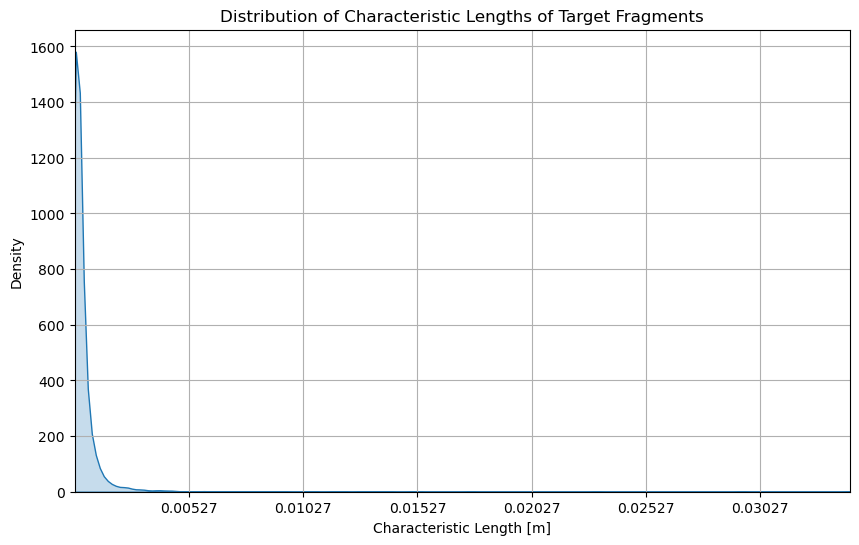

In [34]:
# Distribution of fragments' Characteristic Lengths, considering just Target fragments (id < 8163)
target_fragments = df[df["ID"] < 8163]
characteristic_lengths = target_fragments["Characteristic Length [m]"]

plt.figure(figsize=(10, 6))
# X-axis ends where there are no more fragments
plt.xticks(np.round(np.arange(characteristic_lengths.min(), characteristic_lengths.max(), 0.005), 7))
sns.kdeplot(characteristic_lengths, fill=True)
plt.title("Distribution of Characteristic Lengths of Target Fragments")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Density")
plt.xlim(characteristic_lengths.min(), characteristic_lengths.max())
plt.grid()
plt.show()

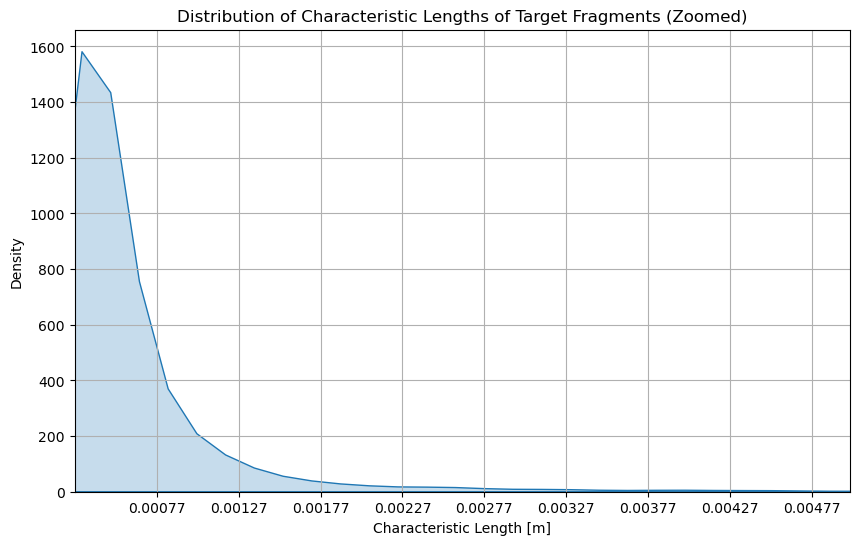

In [35]:
# Zooming in the range of characteristic lengths between 0 and 0.005 m with 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xticks(np.round(np.arange(characteristic_lengths.min(), 0.0051, 0.0005), 7))
sns.kdeplot(characteristic_lengths, fill=True)
plt.title("Distribution of Characteristic Lengths of Target Fragments (Zoomed)")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Density")
plt.xlim(characteristic_lengths.min(), 0.005)
plt.grid()
plt.show()

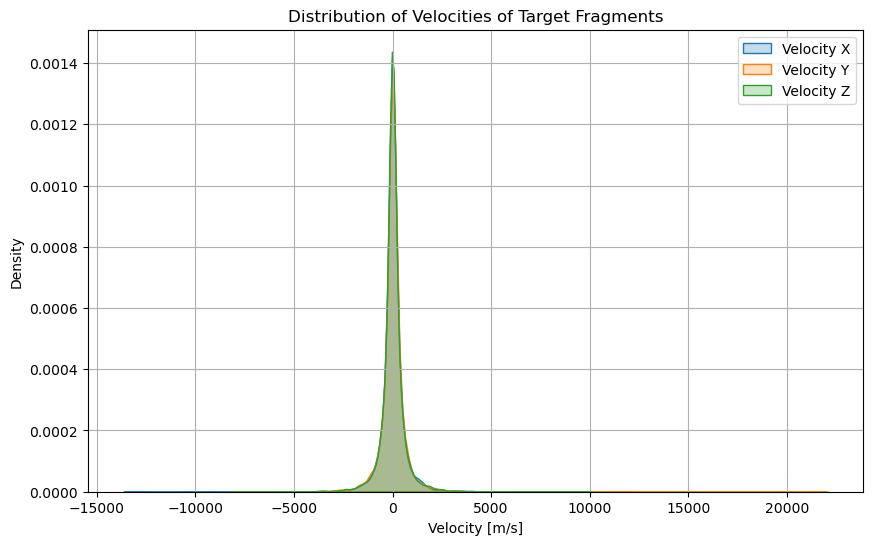

In [39]:
# Dossier of fragments' velocities, considering just Target fragments (id < 8163)
velocities_array = np.array(velocities.tolist())
target_velocities = velocities_array[df["ID"] < 8163]
plt.figure(figsize=(10, 6))
sns.kdeplot(target_velocities[:, 0], fill=True, label='Velocity X')
sns.kdeplot(target_velocities[:, 1], fill=True, label='Velocity Y')
sns.kdeplot(target_velocities[:, 2], fill=True, label='Velocity Z')
plt.title("Distribution of Velocities of Target Fragments")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

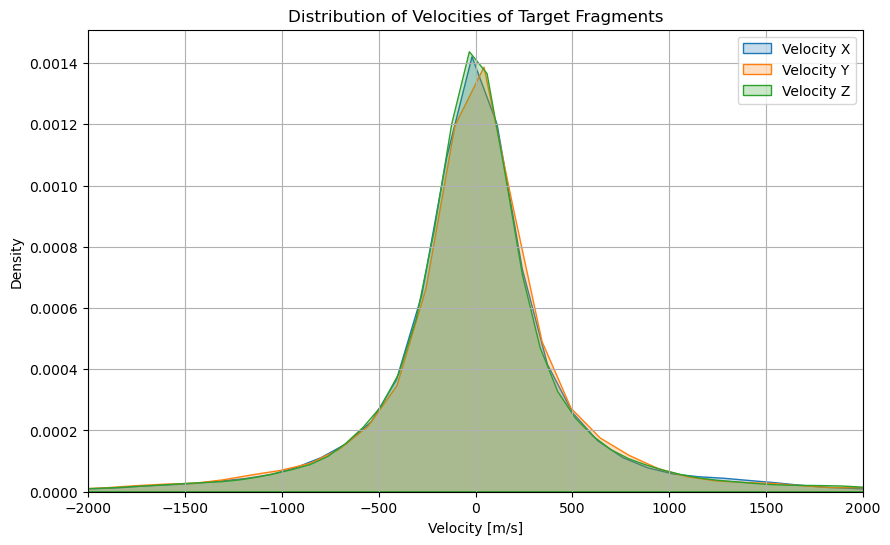

In [40]:
# Dossier of fragments' velocities, considering just Target fragments (id < 8163)
velocities_array = np.array(velocities.tolist())
target_velocities = velocities_array[df["ID"] < 8163]
plt.figure(figsize=(10, 6))
sns.kdeplot(target_velocities[:, 0], fill=True, label='Velocity X')
sns.kdeplot(target_velocities[:, 1], fill=True, label='Velocity Y')
sns.kdeplot(target_velocities[:, 2], fill=True, label='Velocity Z')
plt.xlim(-2000, +2000)
plt.title("Distribution of Velocities of Target Fragments")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

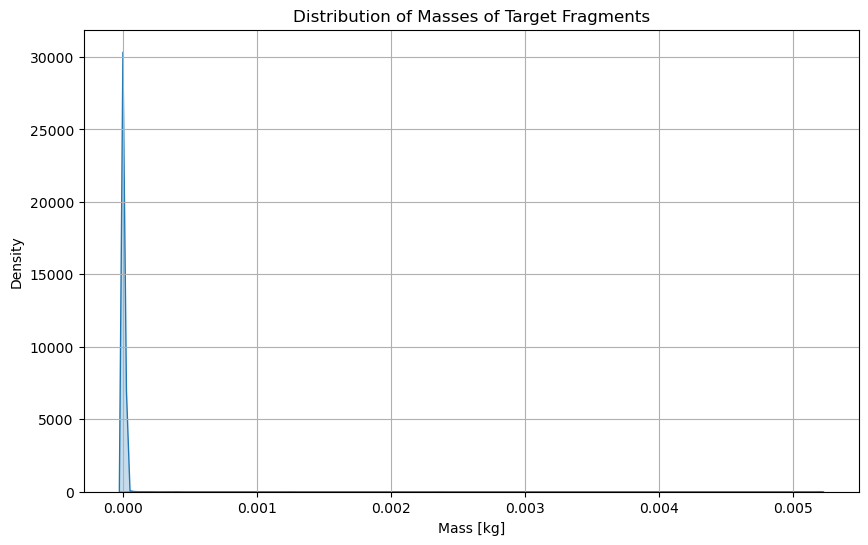

In [43]:
# Distribution of fragments' masses, considering just Target fragments (id < 8163)
target_masses = target_fragments["Mass [kg]"]
plt.figure(figsize=(10, 6))
sns.kdeplot(target_masses, fill=True)
plt.title("Distribution of Masses of Target Fragments")
plt.xlabel("Mass [kg]")
plt.ylabel("Density")
plt.grid()
plt.show()  

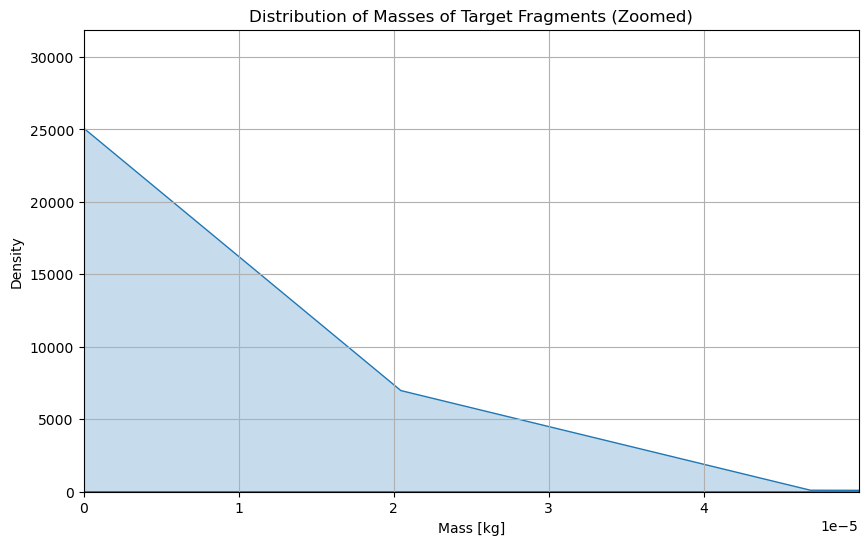

In [49]:
# Zoom in and consider 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xlim(target_masses.min(), 0.00005)
plt.xticks(np.round(np.arange(target_masses.min(), 0.00005, 0.00001), 7))
sns.kdeplot(target_masses, fill=True)
plt.title("Distribution of Masses of Target Fragments (Zoomed)")
plt.xlabel("Mass [kg]")
plt.ylabel("Density")
plt.grid()
plt.show()

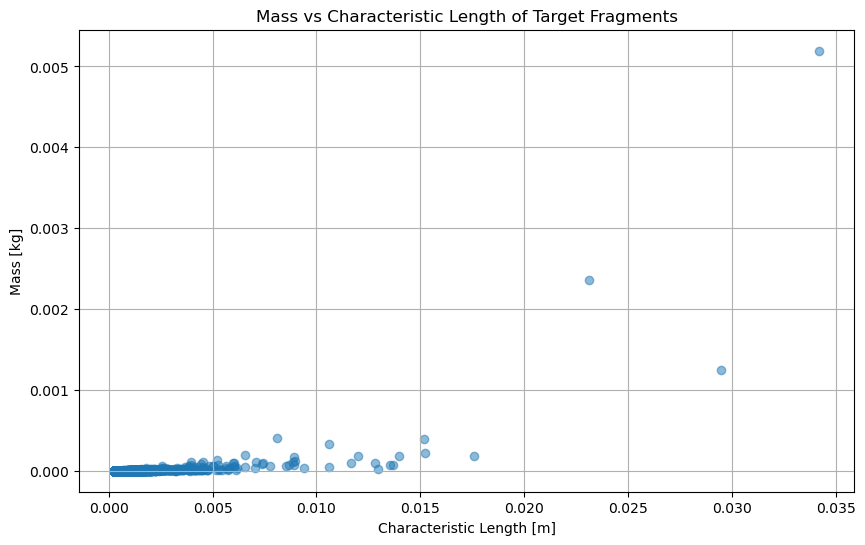

In [50]:
# Point cloud of mass vs characteristic length for Target fragments (id < 8163)
plt.figure(figsize=(10, 6))
plt.scatter(target_fragments["Characteristic Length [m]"], target_fragments["Mass [kg]"], alpha=0.5)
plt.title("Mass vs Characteristic Length of Target Fragments")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Mass [kg]")
plt.grid()
plt.show()

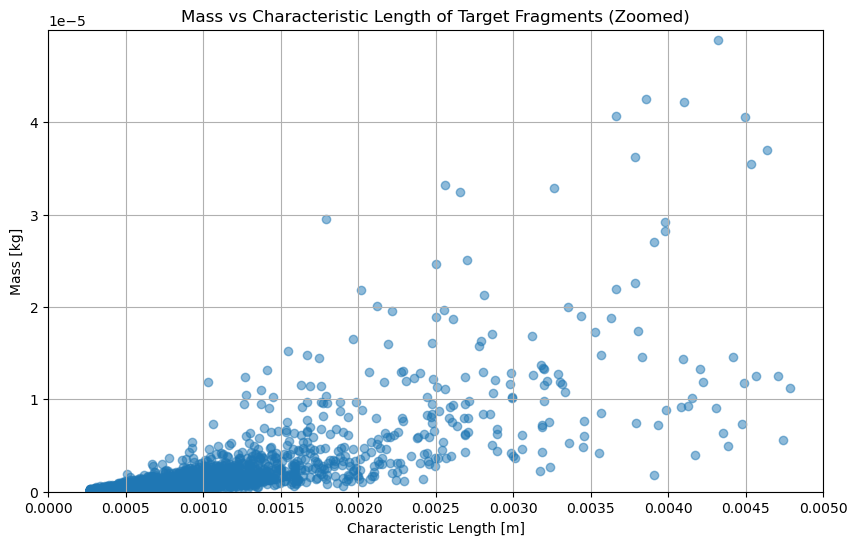

In [51]:
# Zoomed in for Char Length between 0 and 0.005 m and Mass between 0 and 0.00005 kg, with 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xlim(0, 0.005)
plt.ylim(0, 0.00005)
plt.xticks(np.round(np.arange(0, 0.0051, 0.0005), 7))
plt.yticks(np.round(np.arange(0, 0.00005, 0.00001), 7))
plt.scatter(target_fragments["Characteristic Length [m]"], target_fragments["Mass [kg]"], alpha=0.5)
plt.title("Mass vs Characteristic Length of Target Fragments (Zoomed)")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Mass [kg]")
plt.grid()
plt.show()

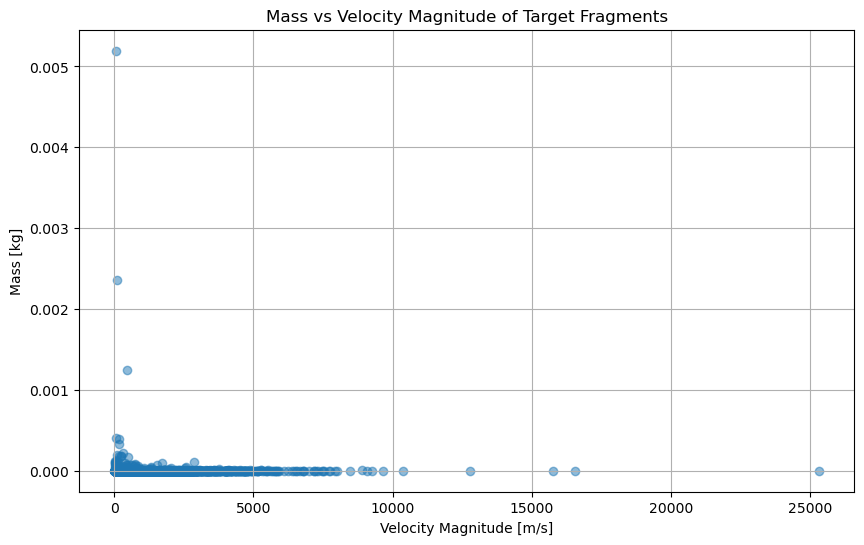

In [52]:
# Point cloud of velocity magnitude vs mass for Target fragments (id < 8163)
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(velocity_magnitudes, target_fragments["Mass [kg]"], alpha=0.5)
plt.title("Mass vs Velocity Magnitude of Target Fragments")
plt.xlabel("Velocity Magnitude [m/s]")
plt.ylabel("Mass [kg]")
plt.grid()
plt.show()

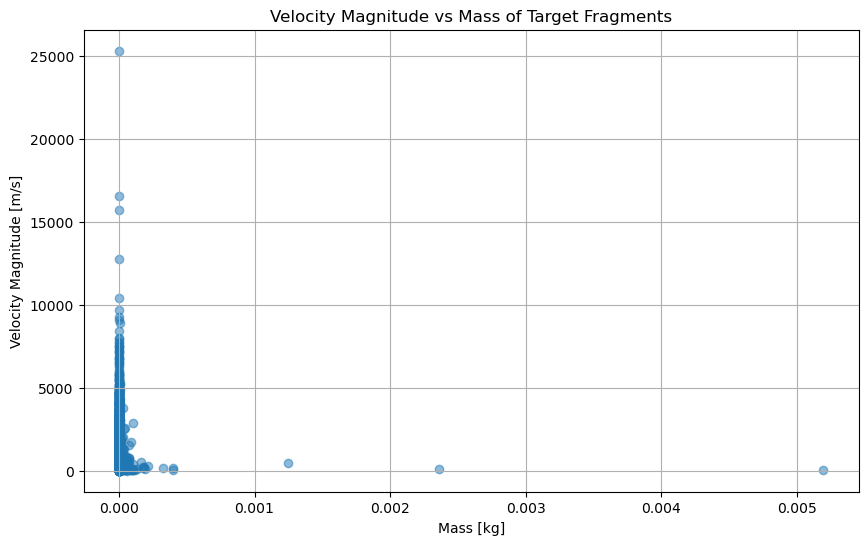

In [53]:
# Let's try the opposite, velocity magnitude vs mass for Target fragments (id < 8163)
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(target_fragments["Mass [kg]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Mass of Target Fragments")
plt.xlabel("Mass [kg]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

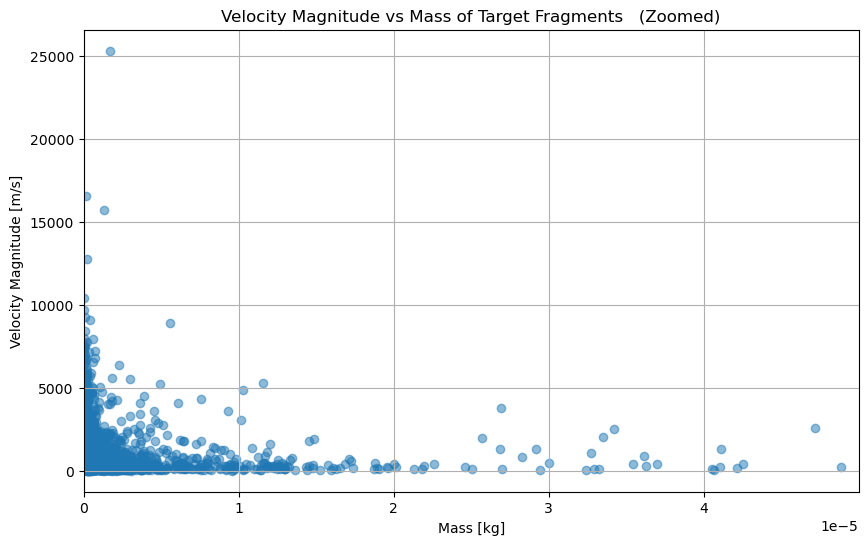

In [54]:
# Zoomed in for mass between 0 and 0.00005 kg, with 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xlim(0, 0.00005)
plt.xticks(np.round(np.arange(0, 0.00005, 0.00001), 7))
plt.scatter(target_fragments["Mass [kg]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Mass of Target Fragments   (Zoomed)")
plt.xlabel("Mass [kg]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

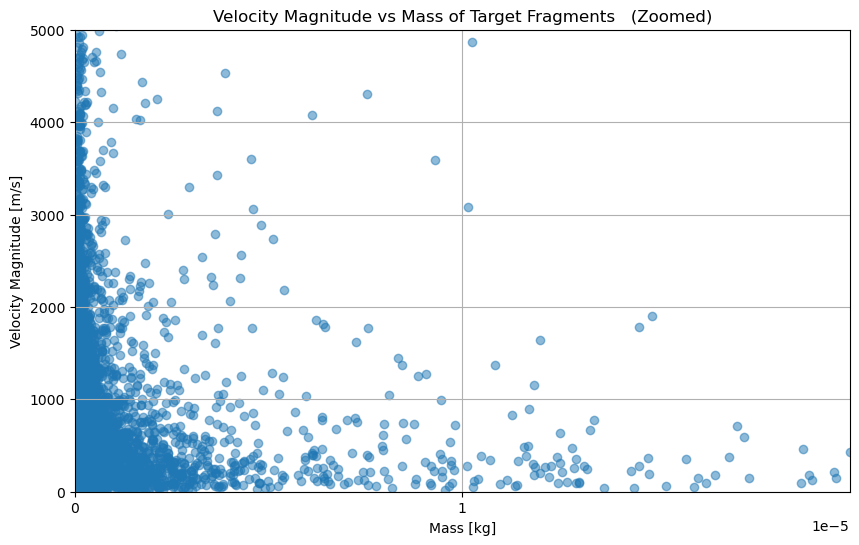

In [55]:
# Zoom for mass between 0 and 0.00002 kg, with 7 decimal places for x ticks, and velocity magnitude between 0 and 5000 m/s
plt.figure(figsize=(10, 6))
plt.xlim(0, 0.00002)
plt.ylim(0, 5000)
plt.xticks(np.round(np.arange(0, 0.00002, 0.00001), 7))
plt.yticks(np.round(np.arange(0, 5001, 1000), 7))
plt.scatter(target_fragments["Mass [kg]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Mass of Target Fragments   (Zoomed)")
plt.xlabel("Mass [kg]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

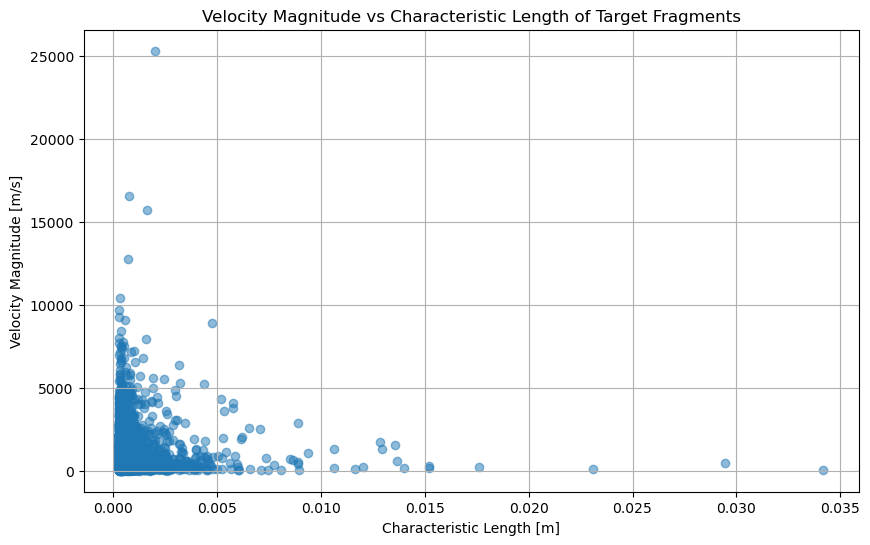

In [56]:
# Point cloud of velocity magnitude vs characteristic length for Target fragments (id < 8163)
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(target_fragments["Characteristic Length [m]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Characteristic Length of Target Fragments")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

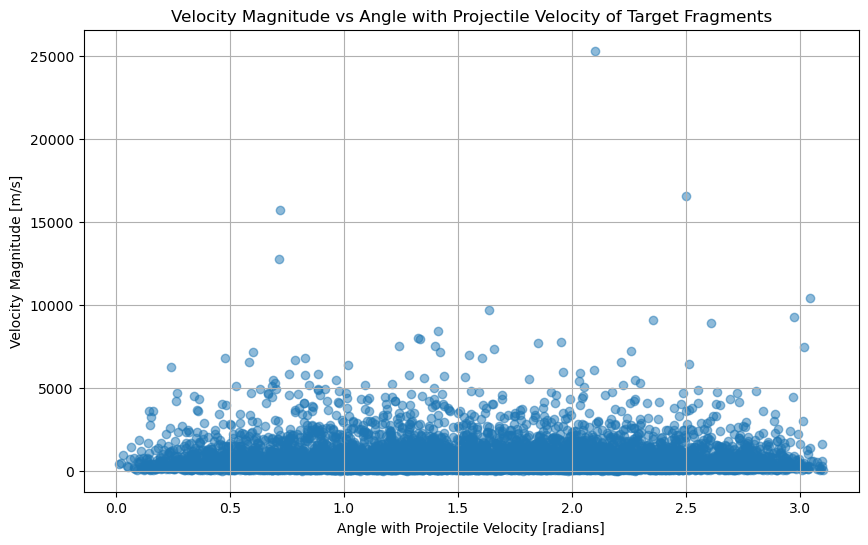

In [57]:
# Point cloud of fragments' velocity magnitude vs the angle between their velocity and the projectile's velocity, for Target fragments (id < 8163)
projectile_velocity = np.array([v_rel, 0, 0])
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
dot_products = np.einsum('ij,j->i', target_velocities, projectile_velocity)
projectile_speed = np.linalg.norm(projectile_velocity)
angles = np.arccos(dot_products / (velocity_magnitudes * projectile_speed + 1e-10))
plt.figure(figsize=(10, 6))
plt.scatter(angles, velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Angle with Projectile Velocity of Target Fragments")
plt.xlabel("Angle with Projectile Velocity [radians]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

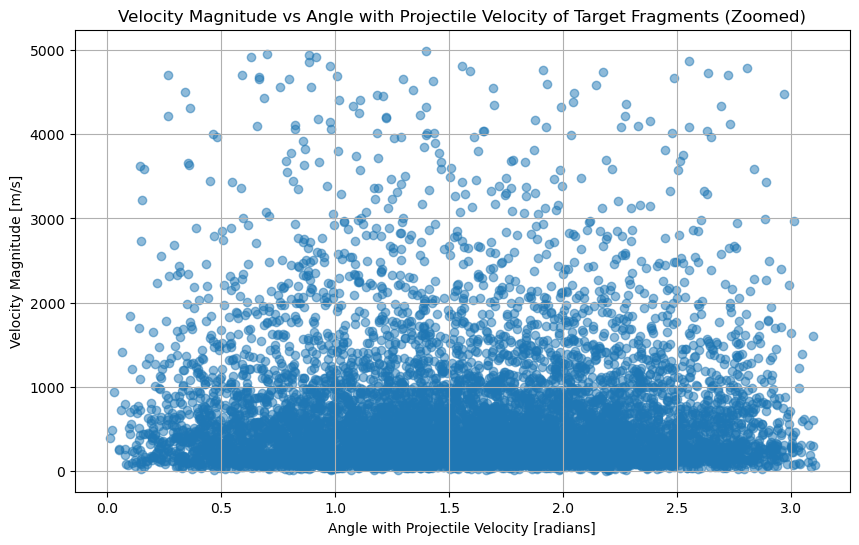

In [59]:
# Lets focus on velocities lower than 5000 m/s for the scatter vs angle with projectile velocity
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
mask = velocity_magnitudes < 5000
plt.figure(figsize=(10, 6))
plt.scatter(angles[mask], velocity_magnitudes[mask], alpha=0.5)
plt.title("Velocity Magnitude vs Angle with Projectile Velocity of Target Fragments (Zoomed)")
plt.xlabel("Angle with Projectile Velocity [radians]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()